# 01 - Embeddings


---

In the previous notebook, we learned why Vector Databases were created.

But one question remains:

How does text become numbers?

This notebook explains Embeddings—the foundation of semantic search and modern AI.

## History

Traditional Machine Learning represented words using:

- Bag of Words
- TF-IDF

These methods ignored semantic meaning.

Researchers wanted words with similar meanings to have similar numerical representations.

This led to **Word Embeddings**.

Today, embeddings are used in:

- RAG
- Chatbots
- Search Engines
- Recommendation Systems
- Vector Databases

##  Think Like a Researcher

Imagine two words:

Car

Automobile

Humans know they have similar meanings.

Can a computer understand that?

Instead of storing words,

what if we store their meaning as vectors?

That idea became Embeddings.

##  What is an Embedding?

An embedding is a dense vector representation of data.

Example

```
Cat
```

↓

```
[0.25, -0.81, 0.63, 0.44]
```

The numbers themselves have no human meaning.

Together, they capture semantic relationships.

In [1]:
embeddings = {
    "Car":[0.91,0.81],
    "Automobile":[0.90,0.83],
    "Dog":[-0.8,-0.7]
}

embeddings

{'Car': [0.91, 0.81], 'Automobile': [0.9, 0.83], 'Dog': [-0.8, -0.7]}

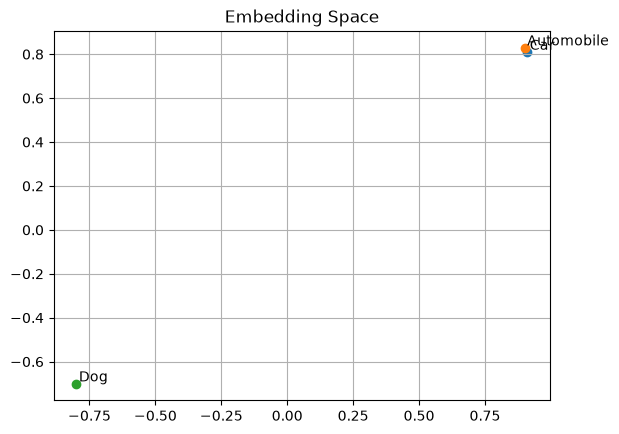

In [2]:
import matplotlib.pyplot as plt

for word,vector in embeddings.items():
    plt.scatter(vector[0],vector[1])
    plt.text(vector[0]+0.01,vector[1]+0.01,word)

plt.grid()
plt.title("Embedding Space")
plt.show()

## Observation

Notice:

Car

and

Automobile

are close together.

Dog

is far away.

Embedding models learn these relationships automatically.

## Sparse vs Dense Embeddings

Sparse Representation

```
[0 0 1 0 0 0 0 1 ...]
```

Mostly zeros.

Dense Representation

```
[0.24 -0.62 0.41 0.15 ...]
```

Almost every value contains information.

Modern AI uses dense embeddings.

## Why Dense Embeddings?

Dense vectors:

- Use less memory
- Capture semantic meaning
- Work well with similarity search
- Generalize better

In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

sentences = [
    "Artificial Intelligence",
    "Machine Learning",
    "Football"
]

vectors = model.encode(sentences)

print(vectors.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(3, 384)


In [2]:
vectors[0][:20]

array([-0.02435099,  0.01670672,  0.03772049, -0.00916331, -0.03058452,
       -0.0170571 ,  0.07420979,  0.04574344, -0.00939855,  0.00990002,
       -0.00570725,  0.00758128,  0.03957975,  0.01521034, -0.08321809,
        0.01934421, -0.02198684, -0.03320648, -0.18101412, -0.13023606],
      dtype=float32)

## Embedding Dimension

The dimension is the number of values in the embedding.

Examples

MiniLM

↓

384

OpenAI text-embedding-3-small

↓

1536

Larger dimensions often capture richer information, but also require more storage and computation.

In [3]:
print(len(vectors[0]))

384


In [4]:
#similarity

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)

similarity

array([[1.        , 0.70346254, 0.31145293],
       [0.70346254, 1.0000005 , 0.2290065 ],
       [0.31145293, 0.2290065 , 1.        ]], dtype=float32)

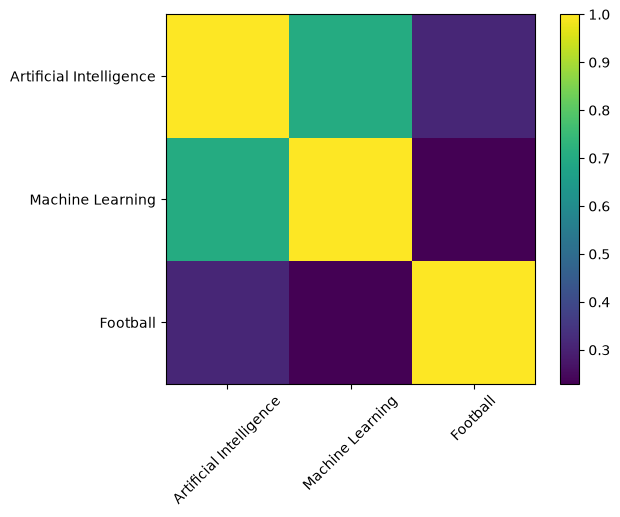

In [5]:
import matplotlib.pyplot as plt

plt.imshow(similarity)

plt.xticks(range(len(sentences)),sentences,rotation=45)

plt.yticks(range(len(sentences)),sentences)

plt.colorbar()

plt.show()

## Observation

Machine Learning

and

Artificial Intelligence

have a higher similarity score.

Football

is much less similar.

The embedding model captured semantic meaning.

## Embedding Models

Popular embedding models include:

- all-MiniLM-L6-v2
- BGE
- E5
- OpenAI Embeddings
- Cohere Embeddings
- Nomic Embed

Each converts text into dense vectors.

## Applications

Embeddings power:

- Semantic Search
- RAG
- Recommendation Systems
- Image Retrieval
- Document Search
- Duplicate Detection
- Clustering

## Limitation

Generating embeddings is only the first step.

Suppose you have:

10 million vectors.

How do you compare them?

One by one?

That would be too slow.

We need similarity metrics and efficient search algorithms.

## Summary

Today I learned:

- What embeddings are
- Dense vs Sparse vectors
- Embedding dimensions
- How to generate embeddings
- How to compare embeddings
- Why embeddings enable semantic search

##  Think Like a Researcher

Great!

Now every document has become a vector.

But another question appears.

Suppose you have two vectors.

How do you measure whether they are similar?

Should we compare:

- Straight-line distance?
- Angle between vectors? 
- Dot product?

This leads to the next topic:

**Distance Metrics.**